### Dataset preparation    
1. split dataset into traset and valset. 
2. show the distribution of the dataset.

In [1]:
import numpy as np
import rasterio as rio 
from glob import glob
import geopandas as gpd
import cartopy.crs as ccrs
from pyrsimg import imgShow
from rasterio import features
import matplotlib.pyplot as plt
from shapely.geometry import Point
import cartopy.feature as cfeature 
from notebooks import config 


In [2]:
### get the secene and truth pairwise data
paths_scene = sorted(glob(config.dir_scene+'*/*.tif'))
paths_truth = sorted(glob(config.dir_truth+'*/*.tif'))
print(len(paths_scene))
print(len(paths_truth)) 


215
215


#### 2. dataset split into traset and valset

In [3]:
ids_scene = [path.split('/')[-1].split('.')[0] for path in paths_scene] 
ids_scene_val = sorted(ids_scene)[::5]  ## every 5th scene for validation
ids_scene_tra = sorted(list(set(ids_scene) - set(ids_scene_val)))
print(f'train data: {len(ids_scene_tra)}, vali data: {len(ids_scene_val)}')
print('train scene ids:', ids_scene_tra)  
print('vali scene ids:', ids_scene_val)    


train data: 172, vali data: 43
train scene ids: ['S2A_L2A_20190125_N0211_R034_6Bands_S2', 'S2A_L2A_20190125_N0211_R034_6Bands_S3', 'S2A_L2A_20190206_N0211_R067_6Bands_S1', 'S2A_L2A_20190206_N0211_R067_6Bands_S2', 'S2A_L2A_20190314_N0211_R008_6Bands_S1', 'S2A_L2A_20190314_N0211_R008_6Bands_S2', 'S2A_L2A_20190314_N0211_R008_6Bands_S3', 'S2A_L2A_20190318_N0211_R061_6Bands_S1', 'S2A_L2A_20190318_N0211_R061_6Bands_S3', 'S2A_L2A_20190426_N0211_R053_6Bands_S1', 'S2A_L2A_20190426_N0211_R053_6Bands_S2', 'S2A_L2A_20190426_N0211_R053_6Bands_S3', 'S2A_L2A_20190429_N0211_R096_6Bands_S2', 'S2A_L2A_20190429_N0211_R096_6Bands_S3', 'S2A_L2A_20190508_N0212_R078_6Bands_S1', 'S2A_L2A_20190508_N0212_R078_6Bands_S2', 'S2A_L2A_20190518_N0212_R073_6Bands_S1', 'S2A_L2A_20190518_N0212_R073_6Bands_S2', 'S2A_L2A_20190518_N0212_R073_6Bands_S3', 'S2A_L2A_20190716_N0213_R063_6Bands_S1', 'S2A_L2A_20190716_N0213_R063_6Bands_S3', 'S2A_L2A_20190724_N0213_R033_6Bands_S1', 'S2A_L2A_20190724_N0213_R033_6Bands_S2', 'S2A_L2A

In [4]:
# get the paths for training and validation sets 
paths_truth_tra = [config.dir_truth+f'{id}.tif' for id in ids_scene_tra]
paths_truth_val = [config.dir_truth+f'{id}.tif' for id in ids_scene_val]
paths_truth_tra[10]  


'data/dset/truth/truth_tif/S2A_L2A_20190426_N0211_R053_6Bands_S2.tif'

In [5]:
import rasterio
from rasterio.warp import transform

def get_image_center_wgs84(path_tif):
    scene_id = path_tif.split('/')[-1].split('.')[0] 
    with rasterio.open(path_tif) as src:
        center_x = src.width / 2
        center_y = src.height / 2
        center_lon, center_lat = src.xy(center_y, center_x)        
        center = (center_lon, center_lat)
        if src.crs and src.crs.to_epsg() != 4326:
            from_crs = src.crs.to_string()
            to_crs = "EPSG:4326"  # WGS84
            lon, lat = transform(from_crs, to_crs, [center_lon], [center_lat])
            center = (lon[0], lat[0])
            return center, scene_id
        else:
            return center, scene_id



In [6]:
paths_truth_tif = sorted(glob(config.dir_truth+'*/*.tif')) 
scene_centers, scene_ids = zip(*[get_image_center_wgs84(path) for path in paths_scene])
print(scene_ids[0], scene_centers[0]) 


l5_scene_01 (119.5704867729241, -29.095217192439915)


In [8]:
dset_gdf = gpd.GeoDataFrame({
  'scene_id': [scene_id for scene_id in scene_ids],
  'satellite': [scene_id[0:2] for scene_id in scene_ids],
  'tra': [True if scene_id in ids_scene_tra else False for scene_id in scene_ids],
  'geometry': [Point(center) for center in scene_centers],
      }, 
  crs='EPSG:4326')
# dset_gdf.to_file('data/dset/dset.gpkg', driver='GPKG') 
dset_gdf.head(5)


,scene_id,satellite,tra,geometry
0,l5_scene_01,l5,False,POINT (119.57049 -29.09522)
1,l5_scene_02,l5,True,POINT (66.38197 59.88031)
2,l5_scene_03,l5,True,POINT (61.77425 46.04525)
3,l5_scene_04,l5,True,POINT (125.44233 63.95019)
4,l5_scene_05,l5,True,POINT (113.91528 22.58003)


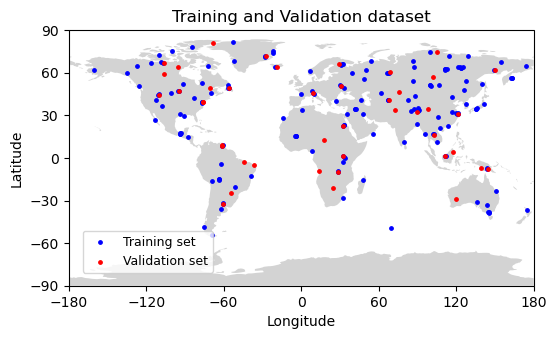

In [9]:
fig, ax = plt.subplots(figsize=(6, 4), 
                subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set_extent([-180, 180, -90, 90])
dset_gdf[dset_gdf['tra']].plot(ax=ax, 
                    markersize=6, 
                    color='blue',
                    label='Training set')
dset_gdf[~dset_gdf['tra']].plot(ax=ax, 
                    markersize=6, 
                    color='red',
                    label='Validation set')
ax.set_title('Training and Validation dataset')
ax.legend(loc=(0.03,0.05), fontsize=9)
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.tick_params(labelsize=10)
fig.savefig('figs/tra_val_split.png', dpi=300)
